In [16]:
# import own data providing functions
from app.data_providers import get_shots_dataframe, main_dataframe, filtered_shots_dataframe
from app.config import TARGET_VARIABLE
from processing.compute_columns import add_is_home_column, add_opponent_interfered_column, add_angle_column, \
    add_shot_main_action_type_column

In [15]:
# getting very raw merged dataframe
df = get_shots_dataframe()

Repo card metadata block was not found. Setting CardData to empty.


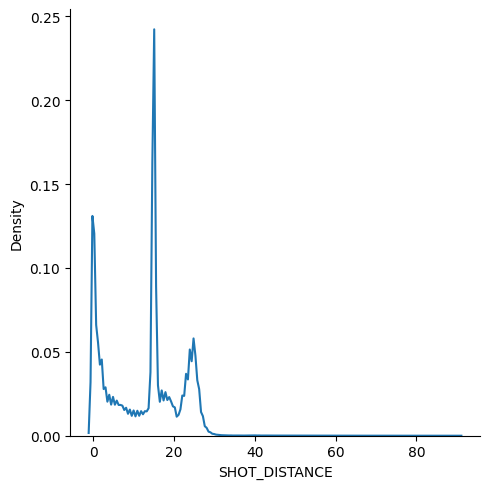

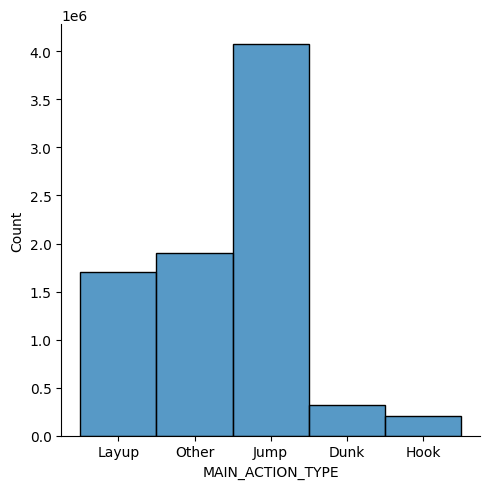

In [12]:
# import plot libraries
import seaborn as sns
import matplotlib.pyplot as plt

# distribution of shot distances and shot techniques
sns.displot(df['SHOT_DISTANCE'], kind = 'kde');
df = add_shot_main_action_type_column(df)
sns.displot(df['MAIN_ACTION_TYPE']);

### Interpretation of shot distance distribution
We have three peaks that can be interpreted as follows:
- Around 0: Dunks + Layups
- Around 15: Free Throws
- Around 23: 3pt
Shots from further away than the three point distance decay very fast. They offer no gain while putting the shot at risk. While a 3pt shot at 23ft is difficult, but has a gain of 1pt/50% compared to, say, a 15ft shot, in addition to the decreased defender density, shots at >23ft only get more risky with no added gain.
### Interpretation of main action type
The majority of shots are jump shots. Dunks and hook shots are comparatively rare, but still present enough to work with, since we have several hundred thousand examples. For this plot, we needed to introduce the concept of a "MAIN_ACTION_TYPE" because the raw ACTION_TYPE is very hard to get an overview over. More time can be invested into analyzing these raw types in detail, because they may reveal information about the difficulty that is lost when grouping. A first thought was that the keyword "fadeaway" might indicate a heightened difficulty that results in a lower success rate.

## Minutes Remaining

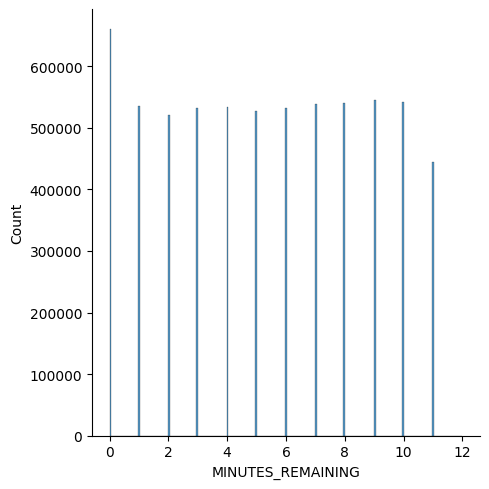

In [8]:
sns.displot(df['MINUTES_REMAINING']);

Shots are distributed quite evenly among the minutes of the period with two exceptions: The first minute (11+ minutes remaining) has slightly less shots, because it begins with the jump-ball and then some time passes before one team can shoot. The last minute seems to imply a lot of literal "last minute shots"

In [8]:
df_filtered_by_players = main_dataframe()

Repo card metadata block was not found. Setting CardData to empty.


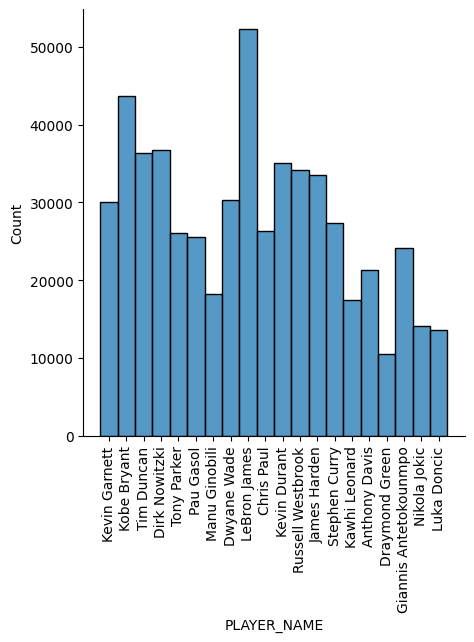

In [14]:
sns.displot(df_filtered_by_players['PLAYER_NAME'])
plt.xticks(rotation=90)
plt.show()

The players are not evenly distributed, so for some, we have significantly more than others. This will be due to their nba career start relative to the datasets timeframe and role in the team. 

## Shot Made (Target)

In [10]:
# Display original dataset's target class distribution
display(df[TARGET_VARIABLE].value_counts(normalize=1))

SHOT_MADE_FLAG
1.0    0.500075
0.0    0.499925
Name: proportion, dtype: float64

The original dataset has a pretty even distribution of misses and hits

In [9]:
# Display original dataset target class distribution filtered by our player choise
display(df_filtered_by_players[TARGET_VARIABLE].value_counts(normalize=1))

SHOT_MADE_FLAG
1.0    0.549169
0.0    0.450831
Name: proportion, dtype: float64

Shots of the great players have a different distribution with more hits.